# Xente Loan Default Project
## 03. Feature Engineering and Selection

Prepared by **OMODING ISAAC (B31331)**

This notebook explains how behavioural, temporal, and transaction-intensity features were engineered, and it records the explicit leakage exclusions used before modelling.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

BASE_DIR = Path.cwd()
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
CLEANED_DIR = BASE_DIR / "outputs" / "cleaned"
PREDICTIONS_DIR = BASE_DIR / "outputs" / "predictions"


In [2]:
leakage = pd.read_csv(METRICS_DIR / 'leakage_and_id_exclusions.csv')
leakage

,feature,decision,reason
0,PaidOnDate,Excluded,This variable is only known after repayment ev...
1,IsFinalPayBack,Excluded,This variable is only known after repayment ev...
2,DueDate,Excluded,This variable is only known after repayment ev...
3,PayBackId,Excluded,This variable is only known after repayment ev...
4,IsThirdPartyConfirmed,Excluded,This variable is only known after repayment ev...
5,CustomerId,Excluded,Dropped as a raw identifier because it labels ...
6,TransactionId,Excluded,Dropped as a raw identifier because it labels ...
7,BatchId,Excluded,Dropped as a raw identifier because it labels ...
8,SubscriptionId,Excluded,Dropped as a raw identifier because it labels ...
9,LoanId,Excluded,Dropped as a raw identifier because it labels ...


In [3]:
feature_selection = pd.read_csv(METRICS_DIR / 'feature_selection_summary.csv')
feature_selection.head(30)

,feature,selected,missing_pct,unique_values,reason
0,Amount,True,0.00,71,Selected as a numeric signal available at pred...
1,InvestorId,True,0.00,3,Selected as a categorical signal available at ...
2,ProductCategory,True,0.00,7,Selected as a categorical signal available at ...
3,ProductId,True,0.00,15,Selected as a categorical signal available at ...
4,Value,True,0.00,87,Selected as a numeric signal available at pred...
5,abs_amount,True,0.00,71,Selected as a numeric signal available at pred...
6,abs_value,True,0.00,87,Selected as a numeric signal available at pred...
7,amount_to_value_ratio,True,0.00,22,Selected as a numeric signal available at pred...
8,amount_value_gap,True,0.00,28,Selected as a numeric signal available at pred...
9,customer_days_since_prev_txn,True,10.62,977,Selected as a numeric signal available at pred...


In [4]:
history_features = pd.read_csv(CLEANED_DIR / 'customer_history_features.csv')
history_features.head()

,row_id,customer_prior_txn_count,customer_prior_abs_amount_sum,customer_prior_abs_value_sum,customer_prior_abs_amount_mean,customer_prior_abs_value_mean,customer_prior_max_abs_amount,customer_days_since_prev_txn,customer_tenure_days,customer_prior_unique_product_categories,customer_prior_unique_channels,customer_prior_same_product_count,customer_prior_same_channel_count,customer_prior_weekend_share
0,TRAIN_97,0,0.0,0.0,NaN,NaN,0.0,NaN,0.000000,0,0,0,0,NaN
1,TRAIN_107,1,5000.0,5000.0,5000.0,5000.0,5000.0,1.944537,1.944537,1,1,0,1,0.000000
2,TRAIN_113,2,7000.0,7000.0,3500.0,3500.0,5000.0,1.476551,3.421088,2,1,1,2,0.500000
3,TRAIN_114,3,9000.0,9000.0,3000.0,3000.0,5000.0,0.025486,3.446574,2,1,1,3,0.333333
4,UNLINKED_11440,4,11000.0,11000.0,2750.0,2750.0,5000.0,86.087002,89.533576,2,1,0,0,0.250000


In [5]:
numeric_tests = pd.read_csv(METRICS_DIR / 'numeric_relationship_tests.csv')
numeric_tests

,feature,default_median,non_default_median,mann_whitney_pvalue,point_biserial_corr,point_biserial_pvalue
0,Amount,-192000.0,-3000.000000,1.629793e-74,-0.333401,5.858386e-40
1,Value,192000.0,3000.000000,2.073717e-74,0.333220,6.484074e-40
2,customer_prior_abs_amount_mean,192000.0,3687.500000,1.397002e-47,0.395524,6.630897e-57
3,customer_prior_abs_value_mean,192000.0,3735.954545,1.566681e-47,0.395225,8.171817e-57
4,customer_prior_txn_count,2.0,13.000000,2.374740e-44,-0.207948,5.340176e-16
5,customer_prior_max_abs_amount,192000.0,11000.000000,4.392553e-08,0.203431,2.306292e-15
6,customer_prior_abs_amount_sum,192000.0,67350.000000,8.550932e-03,0.116496,6.626004e-06
7,customer_prior_abs_value_sum,192000.0,67775.000000,1.038283e-02,0.114978,8.738457e-06


In [6]:
categorical_tests = pd.read_csv(METRICS_DIR / 'categorical_relationship_tests.csv')
categorical_tests

,feature,chi_square_stat,chi_square_pvalue,degrees_of_freedom,highest_defaulting_category,highest_default_rate
0,ProductCategory,741.150633,7.947889e-157,6,retail,0.645570
1,ProductId,744.662348,7.480071e-150,14,ProductId_18,0.645570
2,InvestorId,353.550015,1.688845e-77,2,InvestorId_2,0.374396


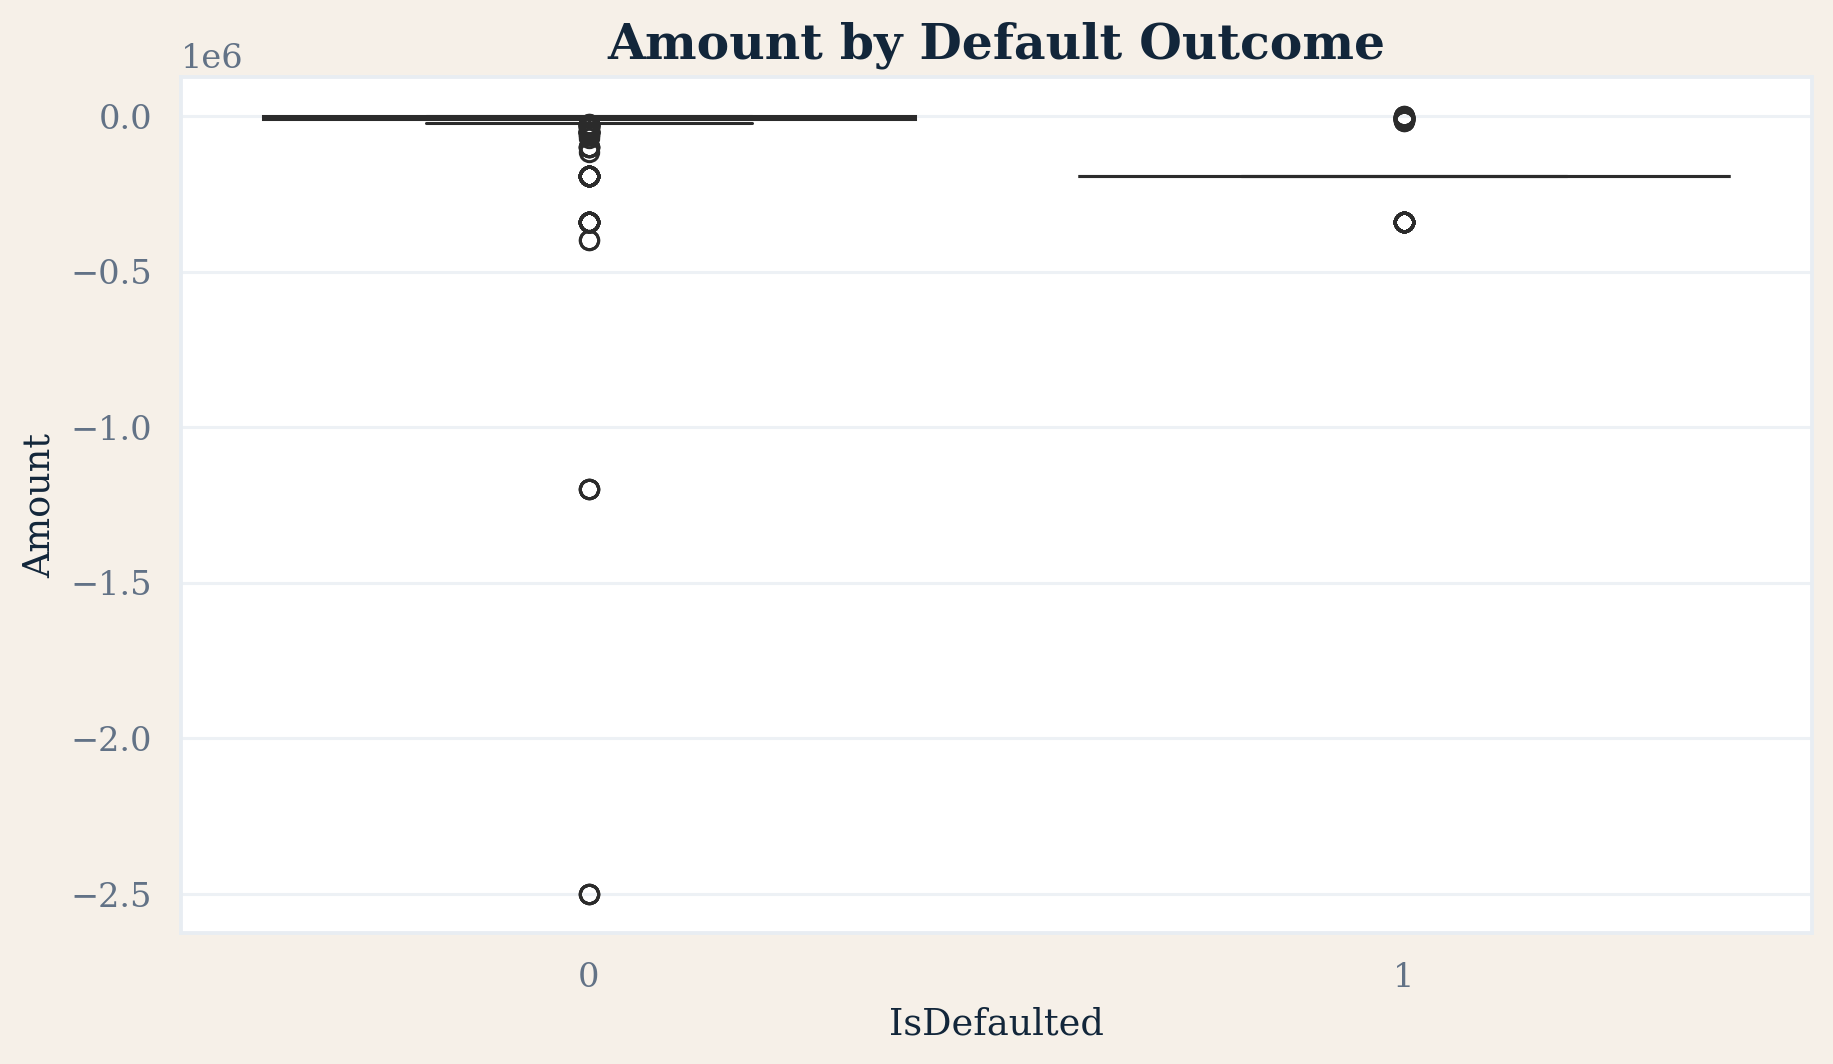

In [7]:
display(Image(filename=str(FIGURES_DIR / 'relationship_numeric_Amount.png'), width=1100))

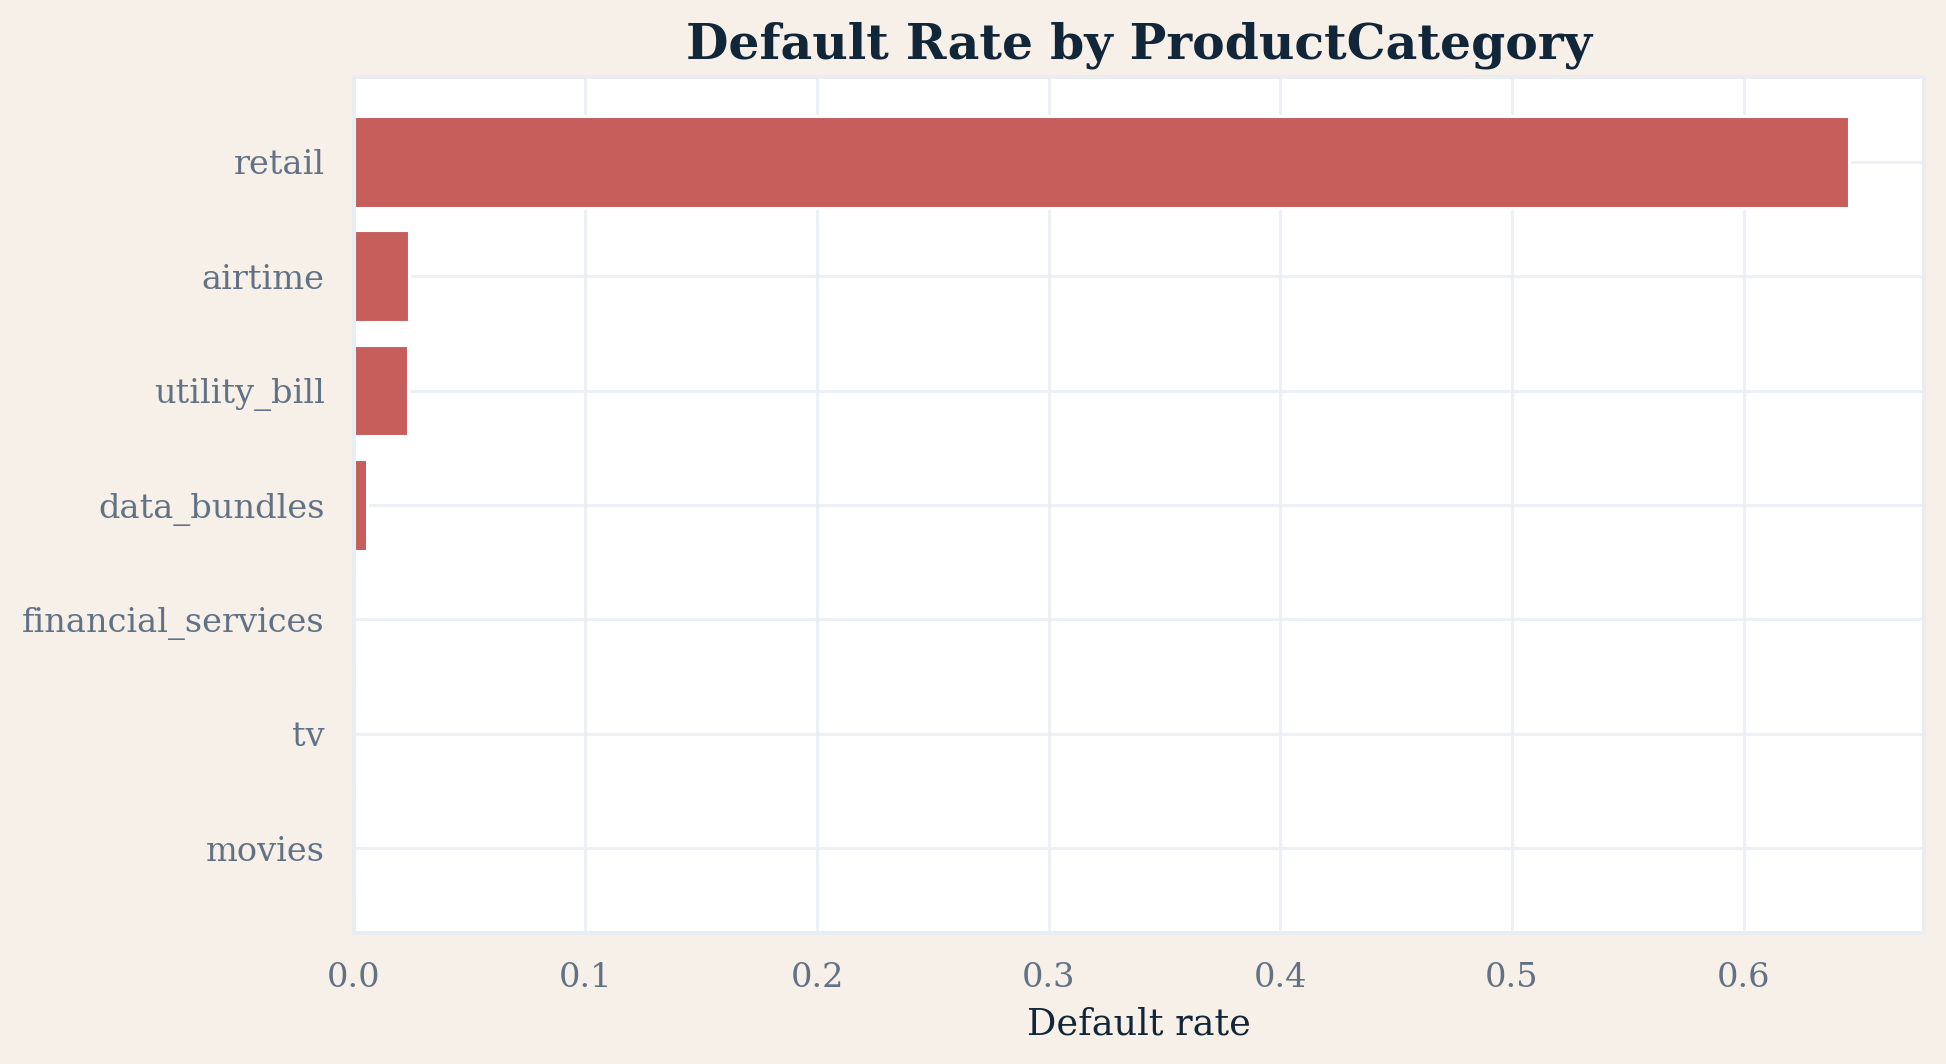

In [8]:
display(Image(filename=str(FIGURES_DIR / 'relationship_categorical_ProductCategory.png'), width=1100))